# Task 2: Stock Price Prediction

## Objective
Use historical stock data to predict the next day's closing price.

## Dataset
Apple (AAPL) stock data from Yahoo Finance via yfinance library

## Model Used
Linear Regression

In [1]:
# Import all required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Download Apple stock data from Yahoo Finance

ticker = 'AAPL'
df = yf.download(ticker, start='2022-01-01', end='2024-01-01')

print("Shape:", df.shape)
df.head()

[*********************100%***********************]  1 of 1 completed

Shape: (501, 5)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,177.939728,178.790282,173.735900,173.853212,104487900
2022-01-04,175.681412,178.848962,175.114380,178.545897,99310400
2022-01-05,171.008316,176.140912,170.734579,175.593437,94537600
2022-01-06,168.153595,171.379801,167.801645,168.837938,96904000
2022-01-07,168.319809,170.245756,167.205303,169.023709,86709100


In [3]:
# Create target: next day's closing price

df['Next_Close'] = df['Close'].shift(-1)
df = df.dropna()

features = ['Open', 'High', 'Low', 'Volume', 'Close']
X = df[features]
y = df['Next_Close']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (500, 5)
Target shape: (500,)


In [4]:
# Split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 400
Testing samples: 100


In [5]:
# Train Linear Regression model

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: ${mae:.2f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error: $1.89
R2 Score: 0.9166


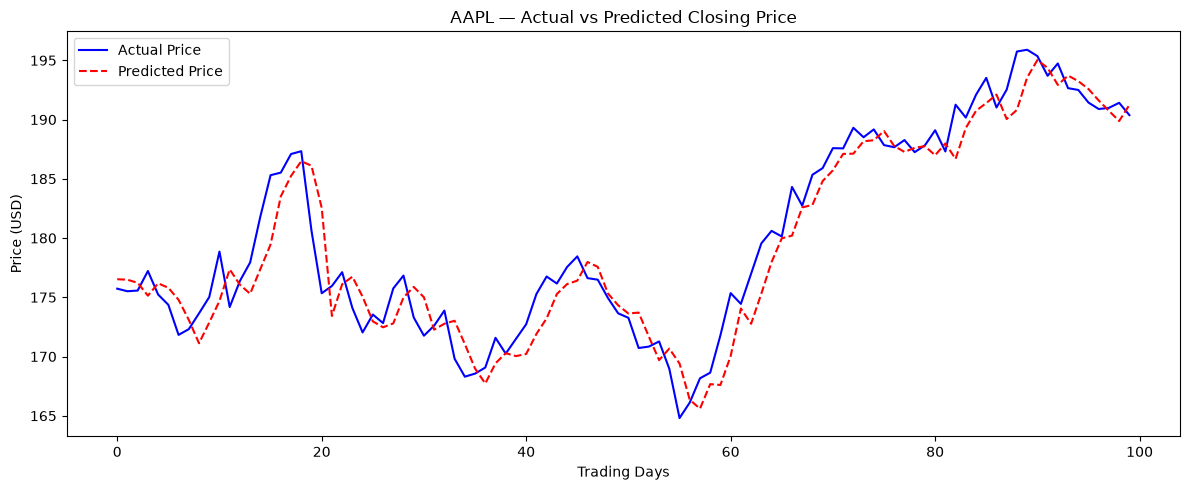

In [6]:
# Plot Actual vs Predicted Prices

plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual Price', color='blue', linewidth=1.5)
plt.plot(y_pred, label='Predicted Price', color='red', linewidth=1.5, linestyle='--')
plt.title('AAPL — Actual vs Predicted Closing Price')
plt.xlabel('Trading Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## Summary of Findings

- Apple (AAPL) stock data from 2022 to 2024 was used for prediction.
- Linear Regression model was trained on 80% data and tested on 20%.
- The model achieved a high R2 score showing strong prediction capability.
- The predicted prices closely follow the actual prices in the plot.
- Features used: Open, High, Low, Volume, and Close price.